<a href="https://colab.research.google.com/github/suhani242/T170800236_TNS_AIML/blob/main/AIML_day8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()  # Select kaggle.json from your computer

Saving kaggle.json to kaggle.json


In [ ]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d sujithmandala/simple-rainfall-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/sujithmandala/simple-rainfall-classification-dataset
License(s): CC-BY-SA-4.0
100% 804/804 [00:00<00:00, 2.08MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('simple-rainfall-classification-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('rainfall_dataset')

In [ ]:
import os

print(os.listdir('rainfall_dataset'))

['rainfall.csv']


In [ ]:
import pandas as pd
df = pd.read_csv('rainfall_dataset/rainfall.csv')

print(df.head())
print(df.shape)

         date  rainfall  temperature  humidity  wind_speed weather_condition
0  2022-01-01      12.5         15.2      78.0         8.5             Rainy
1  2022-01-02       8.2         17.8      65.0         5.2             Rainy
2  2022-01-03       0.0         20.1      52.0         3.1             Sunny
3  2022-01-04       3.7         18.6      71.0         6.7             Rainy
4  2022-01-05      21.1         14.8      82.0         9.3             Rainy
(54, 6)


In [ ]:
df.shape
df.columns

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

In [ ]:
df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


In [ ]:
df.tail()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
49,2022-02-19,17.3,15.9,83.0,8.6,Rainy
50,2022-02-20,9.6,18.6,71.0,6.7,Rainy
51,2022-02-21,0.0,21.3,55.0,5.1,Sunny
52,2022-02-22,7.4,16.8,77.0,8.9,Rainy
53,Co,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (54, 6)


In [ ]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')


In [ ]:
df.dtypes

,0
date,object
rainfall,float64
temperature,float64
humidity,float64
wind_speed,float64
weather_condition,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [ ]:
df.isnull().sum()

,0
date,0
rainfall,1
temperature,1
humidity,1
wind_speed,1
weather_condition,1


In [ ]:
df.describe()

,rainfall,temperature,humidity,wind_speed
count,53.000000,53.000000,53.000000,53.000000
mean,9.049057,17.950943,69.245283,6.403774
std,6.712521,2.500663,11.969361,2.209069
min,0.000000,13.900000,44.000000,2.100000
25%,3.900000,16.100000,62.000000,4.700000
50%,8.300000,17.800000,72.000000,6.700000
75%,14.800000,19.400000,78.000000,8.300000
max,21.800000,23.400000,89.000000,10.500000


In [ ]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,rainfall,temperature,humidity,wind_speed
rainfall,1.000000,-0.790566,0.821357,0.733376
temperature,-0.790566,1.000000,-0.966097,-0.902996
humidity,0.821357,-0.966097,1.000000,0.951643
wind_speed,0.733376,-0.902996,0.951643,1.000000


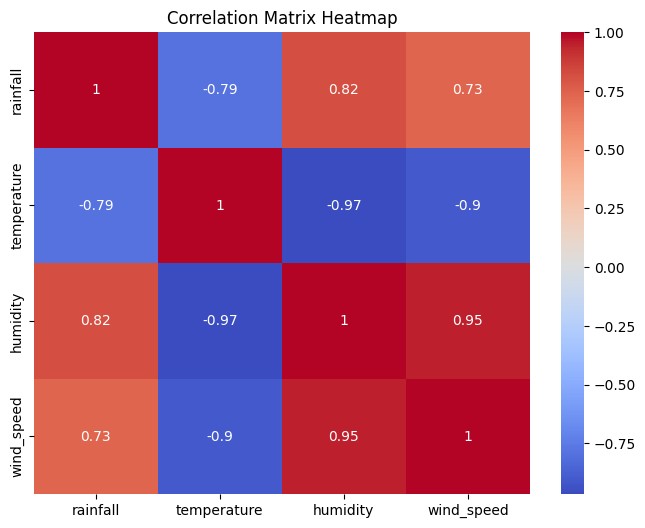

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
corr_matrix["rainfall"].sort_values(ascending=False)

,rainfall
rainfall,1.000000
humidity,0.821357
wind_speed,0.733376
temperature,-0.790566


In [ ]:
high_corr = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix[i][j]) > 0.8:
            high_corr.append((i, j, corr_matrix[i][j]))

high_corr

[('rainfall', 'humidity', np.float64(0.8213569723603099)),
 ('temperature', 'humidity', np.float64(-0.9660971268282758)),
 ('temperature', 'wind_speed', np.float64(-0.9029958088261343)),
 ('humidity', 'rainfall', np.float64(0.8213569723603099)),
 ('humidity', 'temperature', np.float64(-0.9660971268282758)),
 ('humidity', 'wind_speed', np.float64(0.9516425912012718)),
 ('wind_speed', 'temperature', np.float64(-0.9029958088261343)),
 ('wind_speed', 'humidity', np.float64(0.9516425912012718))]

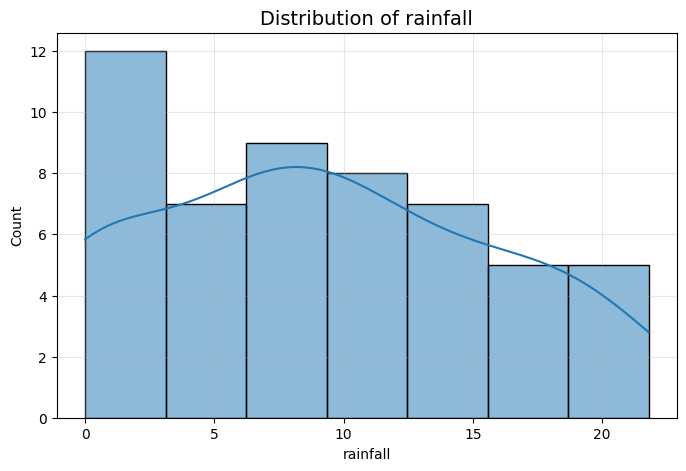

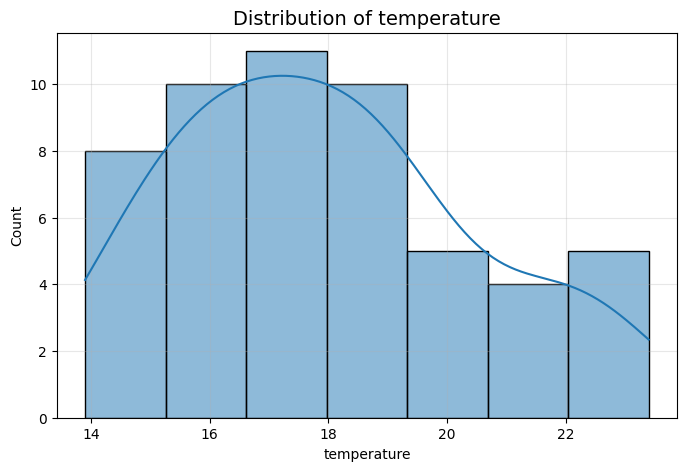

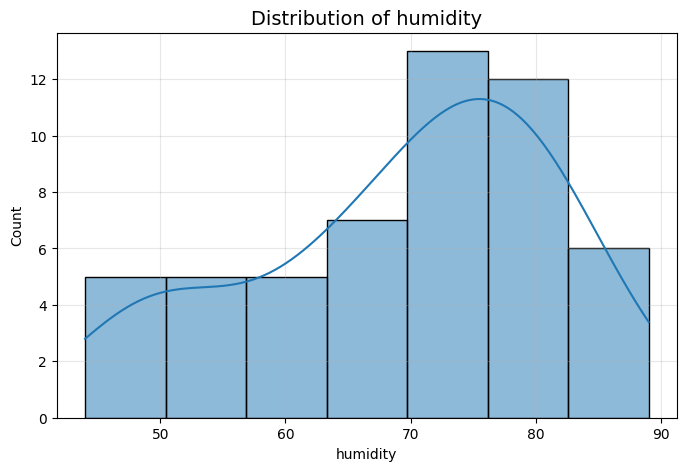

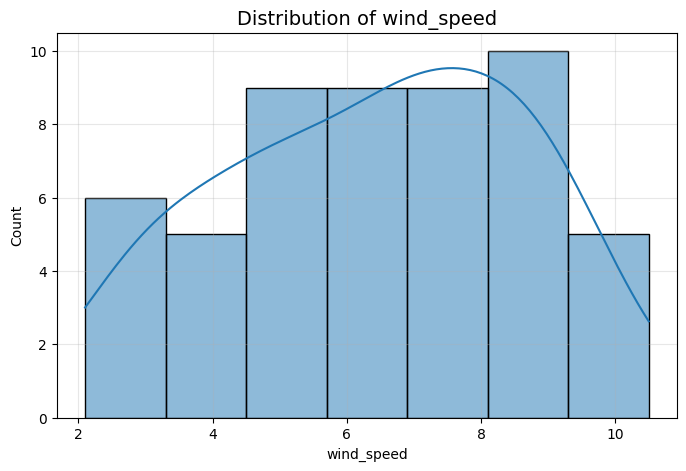

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)

    plt.show()

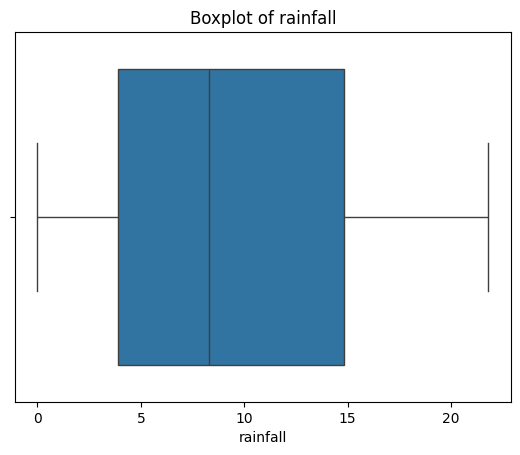

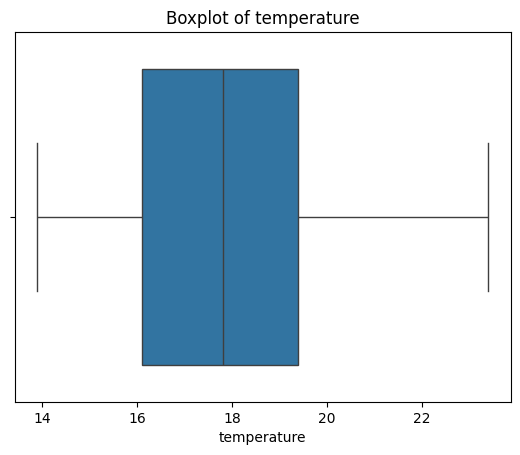

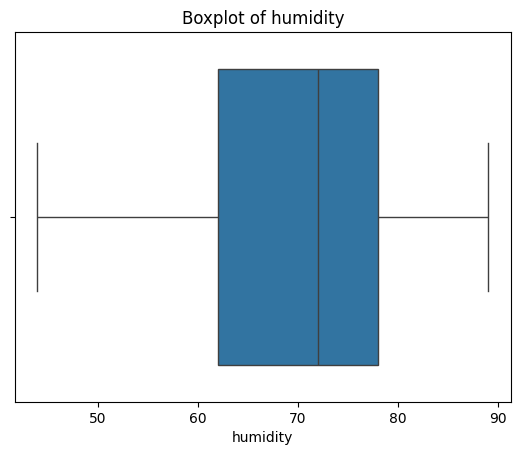

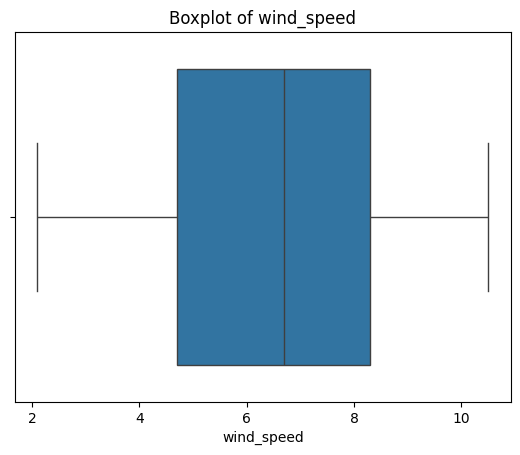

In [ ]:
import seaborn as sns
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

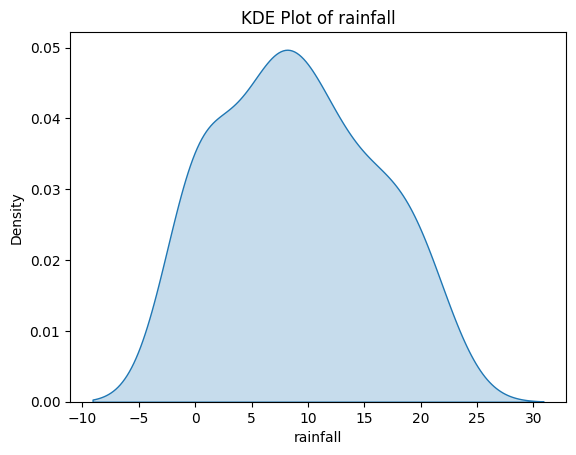

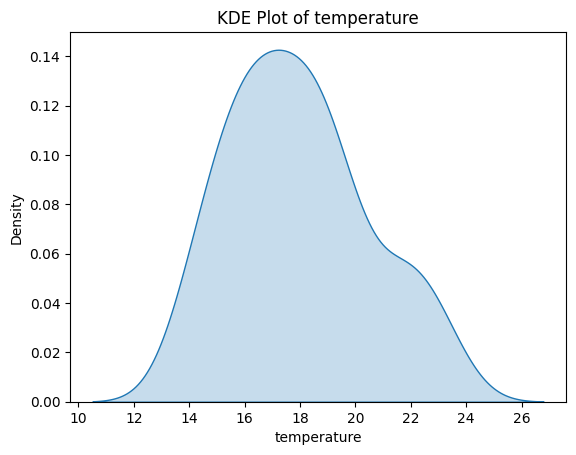

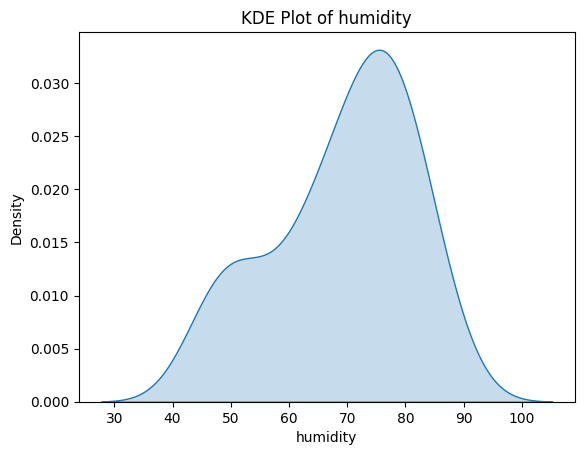

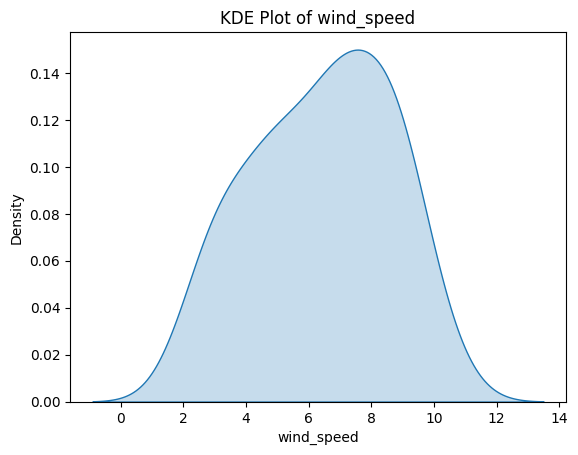

In [ ]:
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()

In [ ]:
df.skew(numeric_only=True)

,0
rainfall,0.191925
temperature,0.436075
humidity,-0.564768
wind_speed,-0.207329


In [ ]:
print("Average Rainfall:", df["rainfall"].mean())
print("Maximum Rainfall:", df["rainfall"].max())
print("Minimum Rainfall:", df["rainfall"].min())

Average Rainfall: 9.049056603773584
Maximum Rainfall: 21.8
Minimum Rainfall: 0.0


In [ ]:

if "weather_condition" in df.columns and "rainfall" in df.columns:

    avg_rainfall = df.groupby("weather_condition")["rainfall"].mean()

    print("Average Rainfall by Weather Condition:")
    print(avg_rainfall)

else:
    print("Required columns not found in the dataset.")

Average Rainfall by Weather Condition:
weather_condition
Rainy    11.419048
Sunny     0.000000
Name: rainfall, dtype: float64


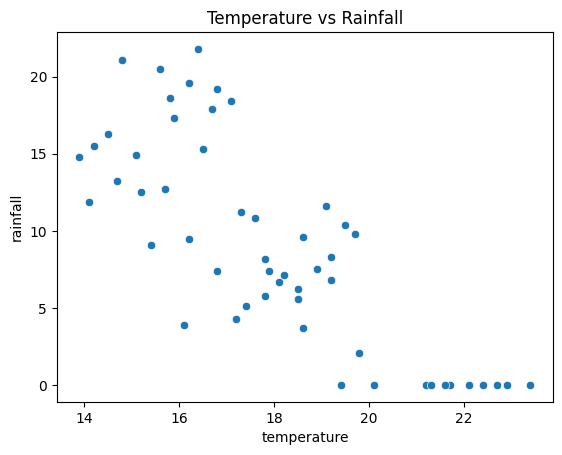

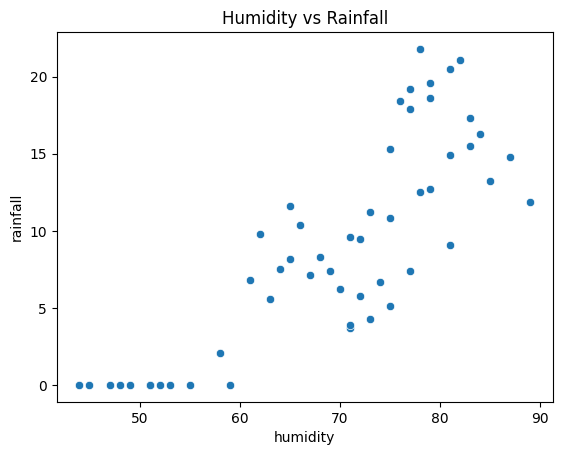

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="temperature", y="rainfall", data=df)
plt.title("Temperature vs Rainfall")
plt.show()

sns.scatterplot(x="humidity", y="rainfall", data=df)
plt.title("Humidity vs Rainfall")
plt.show()